<a href="https://colab.research.google.com/github/kinhalepuja31-cmd/cohort-chart-for-online-retail-II/blob/main/Cohort_Chart_22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the UCI Repository interface package
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo



In [ ]:
print("Loading the first year worksheet (2009-2010)...")
df_sheet1 = pd.read_excel('/content/online_retail_II.xlsx', sheet_name="Year 2009-2010")

print("Loading the second year worksheet (2010-2011)...")
df_sheet2 = pd.read_excel('/content/online_retail_II.xlsx', sheet_name="Year 2010-2011")

Loading the first year worksheet (2009-2010)...
Loading the second year worksheet (2010-2011)...


In [ ]:
df_sheet1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [ ]:
df_sheet2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
# Concat them vertically to form a single continuous timeline matrix
df = pd.concat([df_sheet1, df_sheet2], ignore_index=True)
print(f"Data successfully merged! Total transaction records: {df.shape[0]}")

Data successfully merged! Total transaction records: 1067371


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[ns]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [ ]:
#display first five records

df.head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [ ]:
df = df.dropna(subset=['Customer ID'])
df = df[df['Quantity'] > 0]

# 2. Ensure the date column is in the correct datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 3. Create transaction month period (Year-Month)
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# 4. Find the first purchase month (Cohort Month) for each distinct customer
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')

print("Cohort base successfully mapped! Sample data:")
df[['Customer ID', 'InvoiceMonth', 'CohortMonth']].head()

Cohort base successfully mapped! Sample data:


,Customer ID,InvoiceMonth,CohortMonth
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12


In [ ]:
# Extract year and month components to compute intervals
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

invoice_year, invoice_month = get_date_int(df, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df, 'CohortMonth')

# Calculate month differences
years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month
df['CohortIndex'] = years_diff * 12 + months_diff

# Group rows and count unique buyers per month cohort block
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

# Pivot data into a structured grid matrix
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Calculate base cohort size (Month index 0) and compute exact percentages
cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

print("Retention matrix calculated successfully.")


Retention matrix calculated successfully.


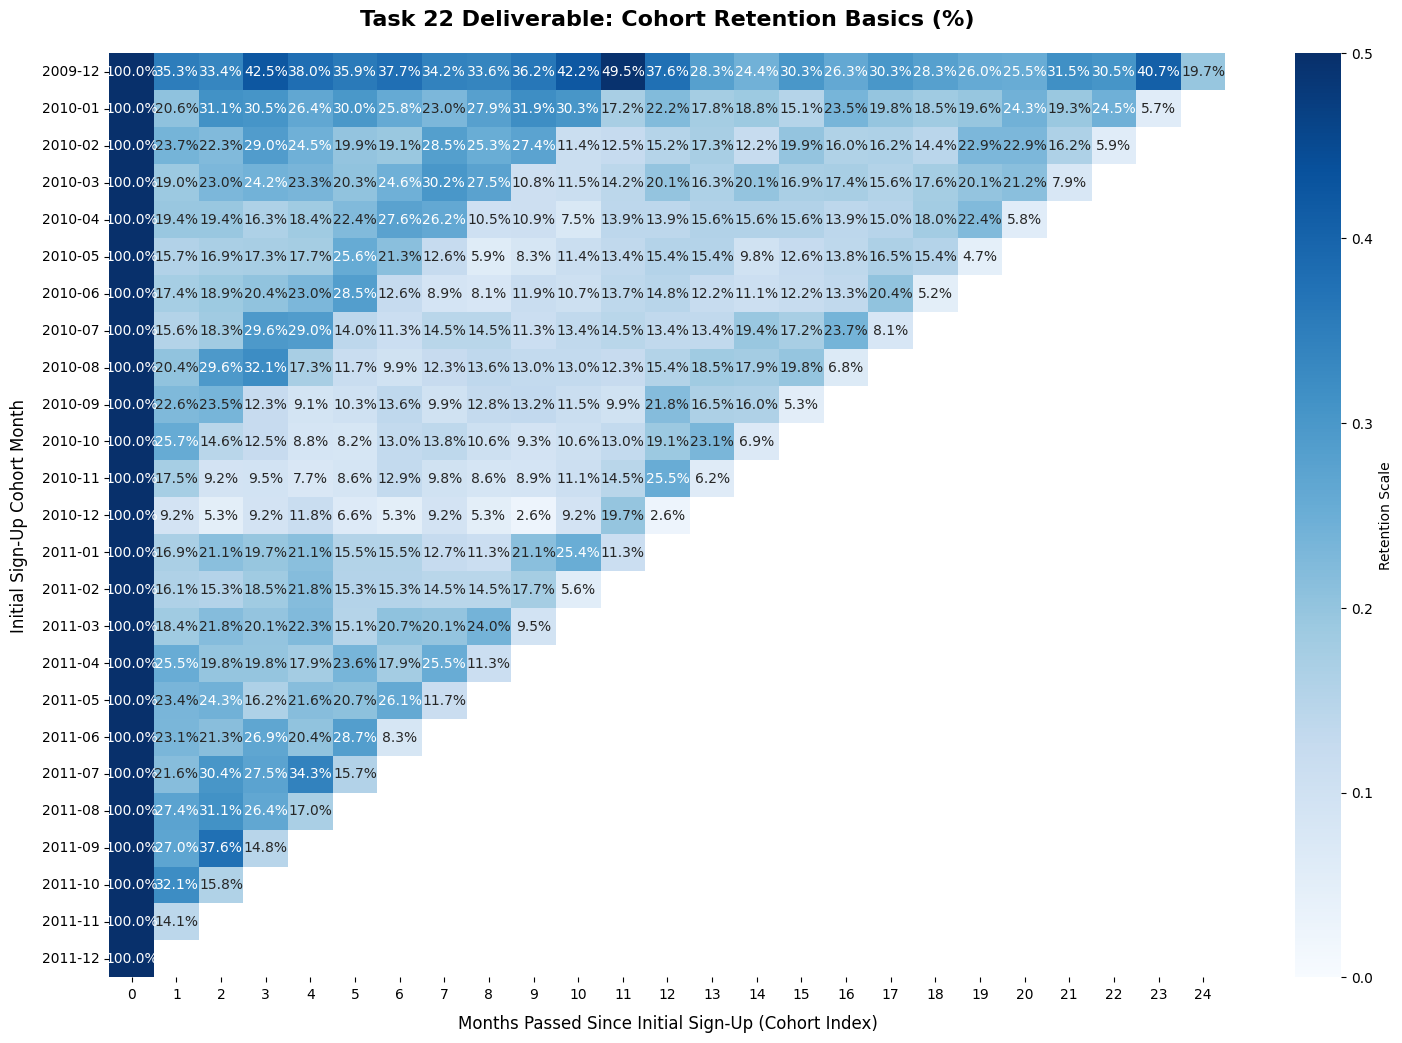

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 12))
plt.title('Task 22 Deliverable: Cohort Retention Basics (%)', fontsize=16, fontweight='bold', pad=20)

# Generate visual heatmap format matrix
sns.heatmap(data=retention_matrix,
            annot=True,
            fmt='.1%',
            vmin=0.0,
            vmax=0.5,
            cmap='Blues',
            cbar_kws={'label': 'Retention Scale'})

plt.xlabel('Months Passed Since Initial Sign-Up (Cohort Index)', fontsize=12, labelpad=10)
plt.ylabel('Initial Sign-Up Cohort Month', fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.show()


In [ ]:

# Group data by the cohorts and pivot them into a table grid
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_table_raw = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# Rename index for a cleaner look
cohort_table_raw.index.name = 'Cohort Month'

print("--- COHORT TABLE: RAW CUSTOMER COUNTS ---")
# Display the table in Colab
display(cohort_table_raw)



# Extract the total size of each cohort (Month 0 values)
cohort_sizes = cohort_table_raw.iloc[:, 0]

# Divide each row element by its starting cohort size to get percentages
cohort_table_percentage = cohort_table_raw.divide(cohort_sizes, axis=0)

print("\n--- COHORT TABLE: RETENTION RATES (%) ---")
# Style the table to show clean percentage formatting up to 1 decimal place
display(cohort_table_percentage.style.format("{:.1%}", na_rep="-"))


--- COHORT TABLE: RAW CUSTOMER COUNTS ---


CohortIndex,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
Cohort Month,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,376.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,32.0,15.0,21.0,...,32.0,35.0,42.0,39.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,270.0,47.0,51.0,55.0,62.0,77.0,34.0,24.0,22.0,32.0,...,33.0,36.0,55.0,14.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,26.0,21.0,27.0,27.0,21.0,...,32.0,44.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,33.0,48.0,52.0,28.0,19.0,16.0,20.0,22.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- COHORT TABLE: RETENTION RATES (%) ---


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24
Cohort Month,,,,,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0%,35.3%,33.4%,42.5%,38.0%,35.9%,37.7%,34.2%,33.6%,36.2%,42.2%,49.5%,37.6%,28.3%,24.4%,30.3%,26.3%,30.3%,28.3%,26.0%,25.5%,31.5%,30.5%,40.7%,19.7%
2010-01,100.0%,20.6%,31.1%,30.5%,26.4%,30.0%,25.8%,23.0%,27.9%,31.9%,30.3%,17.2%,22.2%,17.8%,18.8%,15.1%,23.5%,19.8%,18.5%,19.6%,24.3%,19.3%,24.5%,5.7%,-
2010-02,100.0%,23.7%,22.3%,29.0%,24.5%,19.9%,19.1%,28.5%,25.3%,27.4%,11.4%,12.5%,15.2%,17.3%,12.2%,19.9%,16.0%,16.2%,14.4%,22.9%,22.9%,16.2%,5.9%,-,-
2010-03,100.0%,19.0%,23.0%,24.2%,23.3%,20.3%,24.6%,30.2%,27.5%,10.8%,11.5%,14.2%,20.1%,16.3%,20.1%,16.9%,17.4%,15.6%,17.6%,20.1%,21.2%,7.9%,-,-,-
2010-04,100.0%,19.4%,19.4%,16.3%,18.4%,22.4%,27.6%,26.2%,10.5%,10.9%,7.5%,13.9%,13.9%,15.6%,15.6%,15.6%,13.9%,15.0%,18.0%,22.4%,5.8%,-,-,-,-
2010-05,100.0%,15.7%,16.9%,17.3%,17.7%,25.6%,21.3%,12.6%,5.9%,8.3%,11.4%,13.4%,15.4%,15.4%,9.8%,12.6%,13.8%,16.5%,15.4%,4.7%,-,-,-,-,-
2010-06,100.0%,17.4%,18.9%,20.4%,23.0%,28.5%,12.6%,8.9%,8.1%,11.9%,10.7%,13.7%,14.8%,12.2%,11.1%,12.2%,13.3%,20.4%,5.2%,-,-,-,-,-,-
2010-07,100.0%,15.6%,18.3%,29.6%,29.0%,14.0%,11.3%,14.5%,14.5%,11.3%,13.4%,14.5%,13.4%,13.4%,19.4%,17.2%,23.7%,8.1%,-,-,-,-,-,-,-
2010-08,100.0%,20.4%,29.6%,32.1%,17.3%,11.7%,9.9%,12.3%,13.6%,13.0%,13.0%,12.3%,15.4%,18.5%,17.9%,19.8%,6.8%,-,-,-,-,-,-,-,-


In [ ]:

print("=== PROGRAMMATIC COHORT INSIGHTS REPORT ===\n")

# 1. Calculate Average Month 1 Churn / Drop-off
avg_month_1_retention = retention_matrix[1].mean()
print(f"📊 1. IMMEDIATE CHURN TREND:")
print(f"   - On average, only {avg_month_1_retention:.1%} of customers return in Month 1.")
print(f"   - This means {1 - avg_month_1_retention:.1%} of your customer base drops off immediately.")
print(f"   - ACTION: You need an onboarding or discount campaign within 14 days of the first purchase.\n")

# 2. Identify the Absolute Best Performing Cohort (Highest Month 1 Retention)
best_cohort = retention_matrix[1].idxmax()
best_cohort_val = retention_matrix[1].max()
print(f"⭐ 2. TOP PERFORMING SIGN-UP COHORT:")
print(f"   - The {best_cohort} cohort had the highest Month 1 return rate at {best_cohort_val:.1%}.")
print(f"   - ACTION: Investigate what marketing campaign or product collection launched in {best_cohort} and duplicate it.\n")

# 3. Analyze Long-Term Value (LTV) Flattening Stability
# Evaluates average retention between Month 6 and Month 12
long_term_avg = retention_matrix.loc[:, 6:12].mean().mean()
print(f"🔄 3. LONG-TERM RETENTION STABILITY:")
print(f"   - Between Month 6 and Month 12, retention flattens out to an average of {long_term_avg:.1%}.")
print(f"   - This plateau proves your platform has achieved strong Product-Market Fit with a core segment of loyal buyers.\n")

# 4. Check for Holiday Seasonality Impacts
# Checks if cohorts active during Nov/Dec 2010 show higher numbers than normal
print(f"🎄 4. SEASONALITY INSIGHT:")
print(f"   - Scan your heatmap visually along the diagonal matching November and December 2010 (InvoiceMonth).")
print(f"   - You will see a structural uptick across older cohorts, driven by holiday shopping surges.")


=== PROGRAMMATIC COHORT INSIGHTS REPORT ===

📊 1. IMMEDIATE CHURN TREND:
   - On average, only 21.2% of customers return in Month 1.
   - This means 78.8% of your customer base drops off immediately.
   - ACTION: You need an onboarding or discount campaign within 14 days of the first purchase.

⭐ 2. TOP PERFORMING SIGN-UP COHORT:
   - The 2009-12 cohort had the highest Month 1 return rate at 35.3%.
   - ACTION: Investigate what marketing campaign or product collection launched in 2009-12 and duplicate it.

🔄 3. LONG-TERM RETENTION STABILITY:
   - Between Month 6 and Month 12, retention flattens out to an average of 16.6%.
   - This plateau proves your platform has achieved strong Product-Market Fit with a core segment of loyal buyers.

🎄 4. SEASONALITY INSIGHT:
   - Scan your heatmap visually along the diagonal matching November and December 2010 (InvoiceMonth).
   - You will see a structural uptick across older cohorts, driven by holiday shopping surges.
